# 基礎分析：ジャパンアグリ

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from scipy.optimize import curve_fit

sns.set_style('whitegrid')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meirio']

## データ前処理の前処理

In [2]:
#--変数設定
farm_excel = 'farm/【confidential】サンプルデータ　ジャパンアグリ様②.xlsx'
excel_sheet = 'Sheet1'
output_file = "farm/jpagri_data.csv"

In [3]:
#--Excelデータファイル読み込み
df_org = pd.read_excel(farm_excel, sheet_name=excel_sheet)
print("データ量：元データ", df_org.shape)

#--データ処理(ポリゴン列の削除、年度・経過日の型)
df_org = df_org.drop(columns=['polygon']).dropna().reset_index(drop=True)
df_org['年度'] = df_org['年度'].astype(int)
df_org['経過日'] = df_org['経過日'].astype(int)
print("データ量：データ処理後", df_org.shape)

データ量：元データ (1460, 8)
データ量：データ処理後 (1460, 7)


In [4]:
df_org.head()

,栽培グループ名,年度,圃場名,定植日,収穫日,経過日,NDVI値
0,春レタス（アイスクル）,2022,浜前 20.64a,2022-03-12 00:00:00,2022-05-09 00:00:00,1,0.000000
1,春レタス（アイスクル）,2022,浜前 20.64a,2022-03-12 00:00:00,2022-05-09 00:00:00,6,0.000000
2,春レタス（アイスクル）,2022,浜前 20.64a,2022-03-12 00:00:00,2022-05-09 00:00:00,11,0.000000
3,春レタス（アイスクル）,2022,浜前 20.64a,2022-03-12 00:00:00,2022-05-09 00:00:00,16,0.193220
4,春レタス（アイスクル）,2022,浜前 20.64a,2022-03-12 00:00:00,2022-05-09 00:00:00,21,0.225981


In [5]:
#--レタス品種リスト（ジャパンアグリはすべてレタスの想定）
df_farm = df_org.copy()

#--レタスの品種確認（現状は圃場名出力のみ）
print("栽培グループ名：", len(df_farm['栽培グループ名'].unique()))
print(df_farm['栽培グループ名'].unique())
print("圃場名", len(df_farm['圃場名'].unique()))
print(df_farm['圃場名'].unique())

栽培グループ名： 3
['春レタス（アイスクル）' '春レタス（ブロディ）' '秋レタス（インターセプト）']
圃場名 51
['浜前\u300020.64a' '幸田２\u30001.00a' 'トモコ畑\u300029ａ' '先生脇\u300033.37a'
 '農北\u300020.08a' '小林田\u300029ａ' '日野出口\u300016.14a' 'はく後\u300018.71a'
 'マルミ\u300025.47a' '井戸\u300015.49a' '仁連下\u300019.98a' '仁連長\u300039.29a'
 '先生裏\u300042.10a' '南北\u300028.77a' '和田\u300027.65a' '塚原畑\u300023.55a'
 '大木下\u300039.22a' '大木中\u300036.99a' '宇田裏\u300027.53a' '家\u3000105.54a'
 '小竹前\u300017.42a' '尾崎\u300047.61a' '幸田\u300023.29a' '森畑\u300014.80a'
 '鉄塔\u30009.71a' 'バイパス畑\u300019.77a' '久次郎前\u300012.68a' '前畑\u300011.40ａ'
 '向山\u300032.92a' '和幸\u300014.21a' '大木上\u300042.0a' '江沢畑\u300016.06a'
 '陸田\u300035.19a' 'なす後①\u300050.00a' 'なす後③\u300010a' '人参畑\u300027.09a'
 '宇田前\u300061.22a' '屋敷\u300041.63ａ' '幸田新\u300049ａ' '志辺畑南\u300011.77a'
 '江沢東畑\u300039.67a' '浦畑\u300030.35a' 'おばちゃん隣' 'なす後②\u300013ａ'
 'マルミ脇\u30006.92a' '新開西\u300022.00a' '野球場\u30009.95a' '間林\u300012.23ａ'
 '塚原\u300017.02a' 'トモコ畑脇\u300013ａ' '飯長\u300040a']


In [6]:
#--処理済みデータ書き出し
df_farm.to_csv(output_file, index=False)

## データ前処理

In [2]:
#--変数設定
input_file = "farm/jpagri_data.csv"
remove_list = "farm/jpagri_remove_list.csv"

#--処理済みデータ読み込み
df_farm = pd.read_csv(input_file, parse_dates=['定植日','収穫日'])
#--除外リスト読み込み
df_remove = pd.read_csv(remove_list)

In [3]:
#--解析対象から除外するデータを削除
for index, row in df_remove.iterrows():
    group = row['栽培グループ名']
    field = row['圃場名']
    year = row['年度']
    df_farm = df_farm.query("not (栽培グループ名 == @group and 圃場名 == @field and 年度 == @year)").reset_index(drop=True)

In [4]:
#--栽培グループ名を地区と品種に分割
df_farm[['圃場','広さ']] = df_farm['圃場名'].str.split("　",expand=True)
#--栽培日数(収穫日-定植日)を計算
df_farm['栽培日数'] = (df_farm['収穫日']-df_farm['定植日']).dt.days
#--定植日＋経過日で各データの対象日を計算
df_farm['日付'] = df_farm['定植日'] + pd.to_timedelta(df_farm['経過日'], unit='D')
#--人がわかりやすいように並べ替え
df_farm = df_farm[['栽培グループ名', '圃場名', '圃場', '広さ', '年度', '定植日', '収穫日', '栽培日数', '経過日', '日付', 'NDVI値']]
# df_farm.head()

In [5]:
#--栽培日数よりも長い経過日は削除しておく
df_farm = df_farm.query("栽培日数 >= 経過日").reset_index(drop=True)

#--NDVI値がゼロは、欠損に変えておく
df_farm['NDVI値'] = df_farm['NDVI値'].mask(df_farm['NDVI値']==0, np.nan)

---

## データ分析

### NDVIの時系列グラフ試作

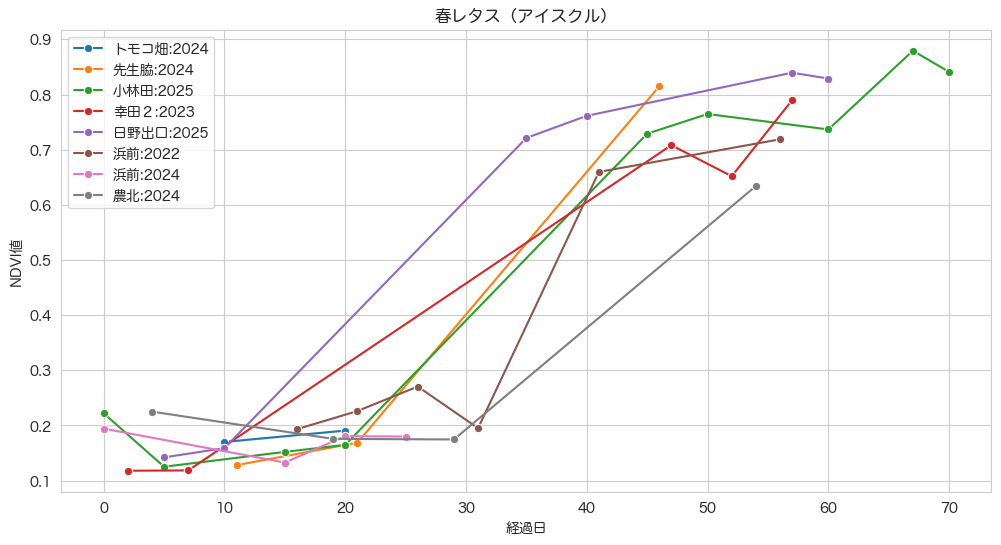

In [5]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場','年度']):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
    plt.legend()
    plt.title(group)
    plt.show()
    break

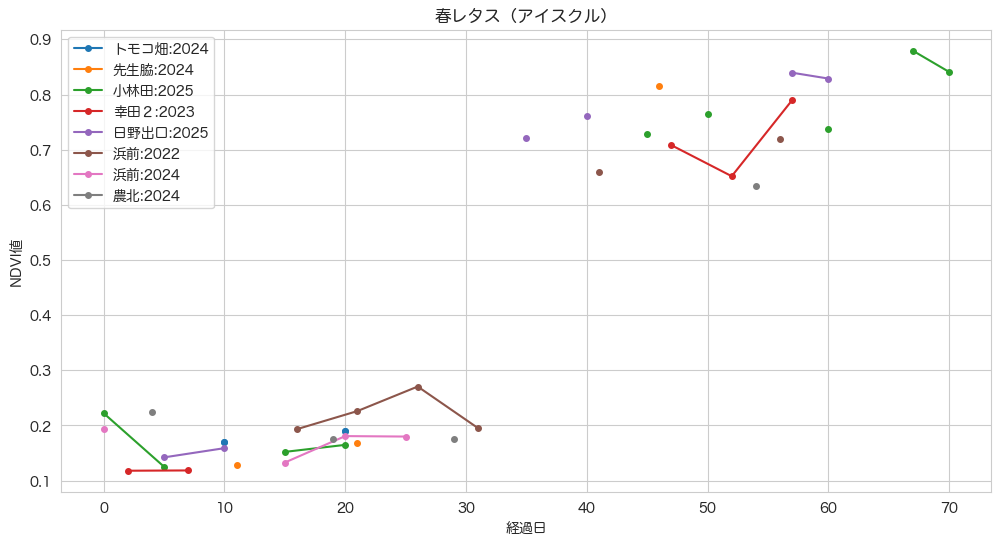

In [6]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場','年度']):
        ax.plot(df['経過日'], df['NDVI値'], '-o', ms=4, label=f'{field}:{year}')
    plt.xlabel("経過日")
    plt.ylabel("NDVI値")
    plt.legend()
    plt.title(group)
    plt.show()
    break

- この栽培グループだけの特殊事例かもだが、定植してから成長過程のNDVIがほとんどなく、成長した後のNDVIに飛んでしまう

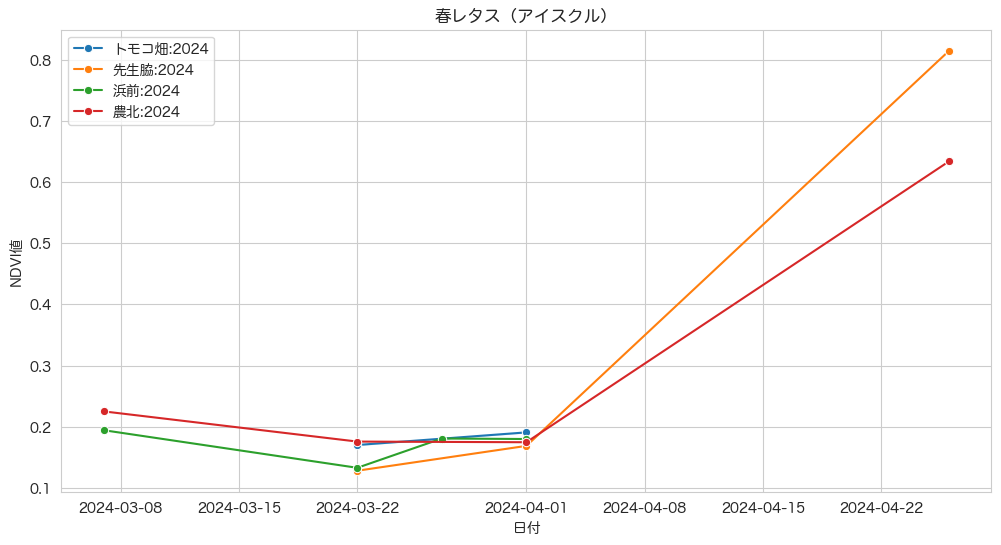

In [12]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        if year != 2024: continue
        fig = plt.figure(figsize=(12,6))
        ax = fig.add_subplot(1,1,1)
        for (field, year), df in df_year.groupby(['圃場','年度']):
            sns.lineplot(data=df, x='日付', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
        plt.legend()
        plt.title(group)
        plt.show()
        break
    break

- 横軸を経過日ではなく対象日の日付にすると、圃場に関わらずほぼ同じようなNDVIの変化となる

### 全部描画（線で繋ぐ版）

In [13]:
#--画像出力先フォルダ作成
fig_dir = "fig/jpagri/line"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場','年度']):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
    ax.set_xlabel("経過日")
    ax.set_ylabel("NDVI値")
    ax.set_title(group)
    ax.legend(
        bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
        loc='upper left',          # 凡例ボックスの基準位置
        borderaxespad=0.,          # グラフとの隙間
        fontsize=9,                # 凡例の文字サイズ（調整可）
    )
    # plt.tight_layout()  # 枠外の凡例が切れないよう調整
    plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

### 全部描画（とびとびあり版）

In [14]:
#--画像出力先フォルダ作成
fig_dir = "fig/jpagri/discrete"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    # print(group)
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場','年度']):
        # print(field,year)
        ax.plot(df['経過日'], df['NDVI値'], '-o', ms=4, label=f'{field}:{year}')
        # sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
    ax.set_xlabel("経過日")
    ax.set_ylabel("NDVI値")
    ax.set_title(group)
    ax.legend(
        bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
        loc='upper left',          # 凡例ボックスの基準位置
        borderaxespad=0.,          # グラフとの隙間
        fontsize=9,                # 凡例の文字サイズ（調整可）
    )
    # plt.tight_layout()  # 枠外の凡例が切れないよう調整
    plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

### 全部描画（線で繋ぐ版・年ごと）
- 圃場ごとの描画だと数が多いため、圃場ごと・年度ごとに分けて描画する

In [15]:
#--画像出力先フォルダ作成
fig_dir = "fig/jpagri/yearly"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        fig = plt.figure(figsize=(12,6))
        ax = fig.add_subplot(1,1,1)
        for field, df in df_year.groupby('圃場'):
            sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=field, ax=ax)
        ax.set_xlabel("経過日")
        ax.set_ylabel("NDVI値")
        ax.set_title(f"{group} : {year}年度")
        ax.legend(
            bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
            loc='upper left',          # 凡例ボックスの基準位置
            borderaxespad=0.,          # グラフとの隙間
            fontsize=9,                # 凡例の文字サイズ（調整可）
        )
        # plt.tight_layout()  # 枠外の凡例が切れないよう調整
        plt.savefig(f"{fig_dir}/{group}_{year}.png", bbox_inches='tight')
        plt.close()
        # plt.show()

### 全部描画（線で繋ぐ版・年ごと）
- 横軸を経過日ではなく対象日の日付にした図も作成しておく

In [16]:
#--画像出力先フォルダ作成
fig_dir = "fig/jpagri/dateaxis"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        fig = plt.figure(figsize=(12,6))
        ax = fig.add_subplot(1,1,1)
        for field, df in df_year.groupby('圃場'):
            sns.lineplot(data=df, x='日付', y='NDVI値', marker='o', label=field, ax=ax)
        ax.set_xlabel("経過日")
        ax.set_ylabel("NDVI値")
        ax.set_title(f"{group} : {year}年度")
        ax.legend(
            bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
            loc='upper left',          # 凡例ボックスの基準位置
            borderaxespad=0.,          # グラフとの隙間
            fontsize=9,                # 凡例の文字サイズ（調整可）
        )
        # plt.tight_layout()  # 枠外の凡例が切れないよう調整
        plt.savefig(f"{fig_dir}/{group}_{year}.png", bbox_inches='tight')
        plt.close()
        # plt.show()

### 同一グループ・同年度の圃場における定植日・収穫日の重複の確認
- トップリバーのデータには、同一圃場・年度で複数の定植日・収穫日があった
- 同様のケースがないか調べる

In [17]:
#--定植日に重複がある圃場・年度を書き出す
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        for field, df in df_year.groupby('圃場名'):
            if len(df['定植日'].unique()) > 1:
                print(group, field, year)

### 各種統計量の分析

In [18]:
#--栽培グループごとに栽培日数の統計量を計算
df_days = df_farm.drop_duplicates(subset=['栽培グループ名','圃場','年度'], keep='last').reset_index(drop=True)
df_days.groupby('栽培グループ名').aggregate({'栽培日数':['mean','std','min','max','count']}).round(1)

栽培日数                    
               mean   std min max count
栽培グループ名                                
春レタス（アイスクル）    63.8   5.8  58  73     8
春レタス（ブロディ）     66.4  11.0  18  83    76
秋レタス（インターセプト）  48.6   4.8  41  62    23

- 春レタス・プロディはデータ数が多いこともあるが、分散が相対的に大きい（圃場ごとの違いが大きい）

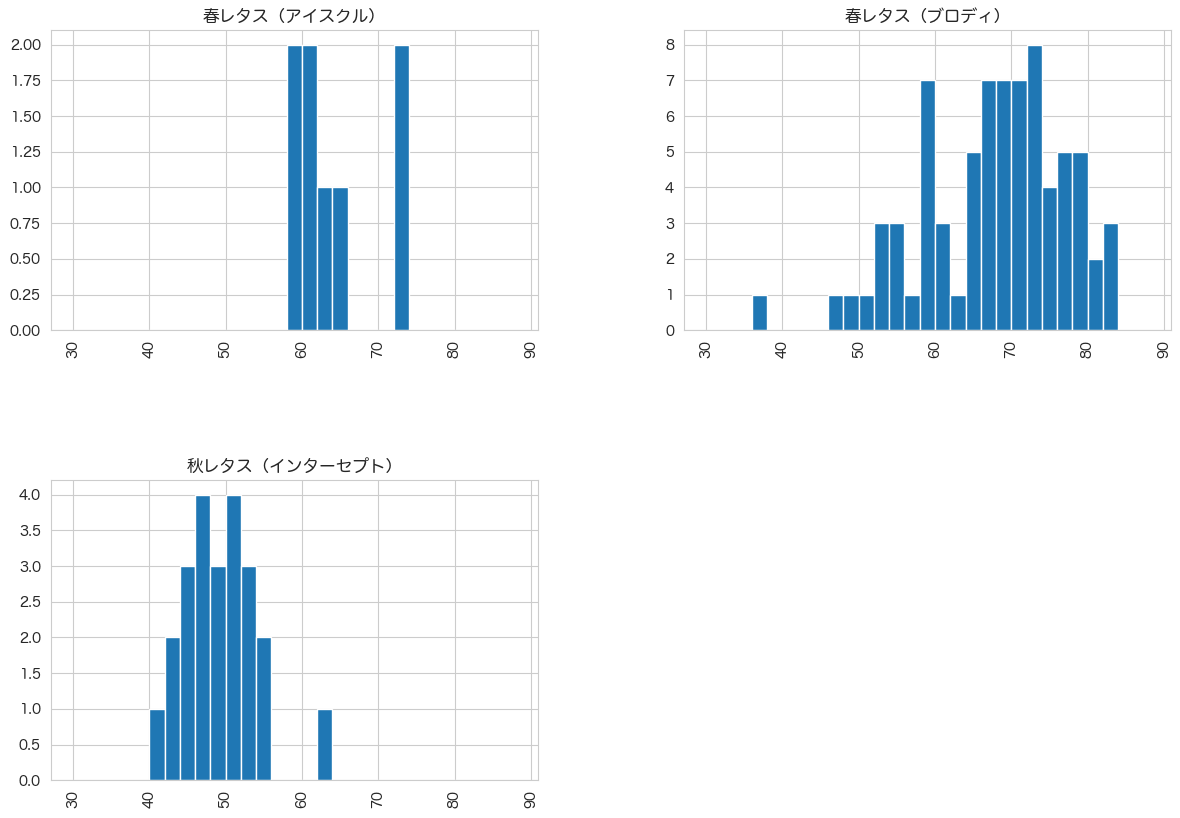

In [21]:
#--栽培グループ名ごとのヒストグラム作成
axes = df_days.hist('栽培日数', by='栽培グループ名', layout=(2,2), bins=np.arange(30,90,2), figsize=(14,10))
plt.show()

In [22]:
#--NDVIの統計量：栽培グループごとに計算
df_ndvi = df_farm.dropna().drop_duplicates(subset=['栽培グループ名','圃場','年度'], keep='last').reset_index(drop=True)
df_ndvi.groupby('栽培グループ名').aggregate({'NDVI値':['mean','std','min','max','count']}).round(2)

NDVI値                        
               mean   std   min   max count
栽培グループ名                                    
春レタス（アイスクル）    0.62  0.28  0.18  0.84     8
春レタス（ブロディ）     0.50  0.17  0.03  0.82    75
秋レタス（インターセプト）  0.69  0.10  0.41  0.82    23

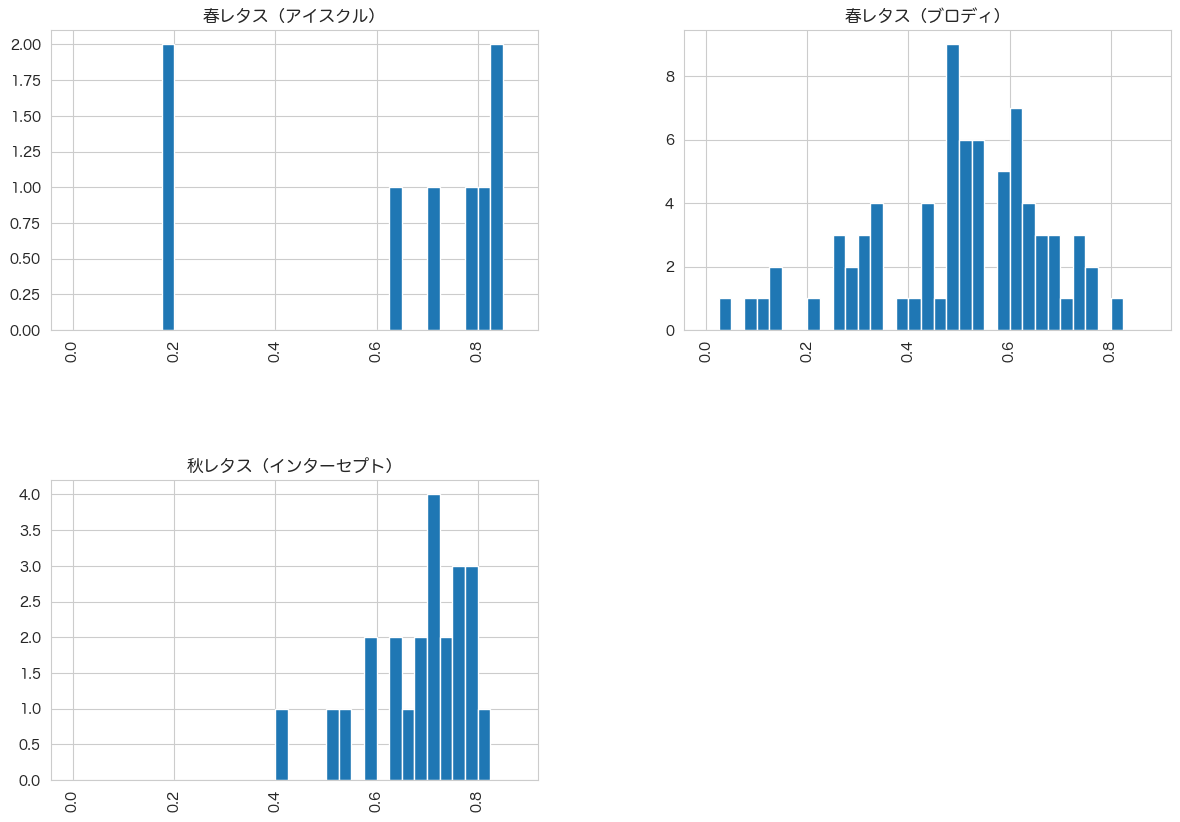

In [24]:
#--栽培グループ名ごとのヒストグラム作成
axes = df_ndvi.hist('NDVI値', by='栽培グループ名', layout=(2,2), bins=np.arange(0,0.9,0.025), figsize=(14,10))
plt.show()

- 相対的には春レタス・プロディは、他の品種に比べてNDVIの平均値が小さめ
- ヒストグラムにすると、同一品種でも収穫直前のNDVIの分散が大きい
    - 収穫日を定植日からの日数で経験的に決めてないか
    - もしくは収穫作業のできる天気の条件があって収穫日が前後するのか
    - もしくはNDVIの解析誤差か

---

## 気象データを使った分析

### データ読み込み

In [9]:
#--変数設定
farm_list = "farm/jpagri_farm.csv"

#--圃場IDリスト読み込み
df_IDs = pd.read_csv(farm_list)

#--圃場IDを栽培データに結合
df_farm = pd.merge(df_farm, df_IDs.get(['圃場名','field_id']), on='圃場名', how='left')

In [11]:
#--分析で使用する気象データ読み込み
df_weather = {}
df_climate = {}
for fid in df_farm['field_id'].unique():
    dfw = pd.read_csv(f"weather/jpagri/weather_{fid}.csv", parse_dates=['date'])
    dfc = pd.read_csv(f"climate/jpagri/climate_{fid}.csv", parse_dates=['date'])
    df_weather[fid] = dfw
    df_climate[fid] = dfc

### 栽培日数と気象データの分析

In [12]:
#--ユニークな圃場・栽培日数のデータセット作成
df_grow = df_farm.drop_duplicates(subset=['栽培グループ名','圃場名','年度'], keep='last').reset_index(drop=True)

#--栽培期間における気象データの合計値を計算
# Tbase = 4
wx_sum_list = []
wx_cols = None
for index, row in df_grow.iterrows():
    fid = row['field_id']
    s_date = row['定植日']
    e_date = row['収穫日']
    # print(fid, s_date, e_date)
    df = df_weather[fid].query("date >= @s_date and date <= @e_date").reset_index(drop=True)
    df['TMP_GDD2'] = (df['TMP_mea'] - 2).clip(lower=0).round(2)
    df['TMP_GDD4'] = (df['TMP_mea'] - 4).clip(lower=0).round(2)
    df['TMX_GDD6'] = (df['TMP_max'] - 6).clip(lower=0).round(2)
    df['TMX_GDD10'] = (df['TMP_max'] - 10).clip(lower=0).round(2)
    sr = df.set_index('date').sum(axis=0).round(2)
    if wx_cols is None:
        wx_cols = sr.index.tolist()
    wx_sum_list.append(sr.tolist())

df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

#--圃場・栽培日数データに気象データを結合
df_grow = pd.concat([df_grow, df_wx_sum], axis=1)

In [25]:
# for grp, df in df_grow.groupby('栽培グループ名'):
#     print(f"--- {grp} ---")
#     print(df['定植日'].value_counts().sort_index())
#     print()

- ブロディの定植時期は1月〜3月とかなり幅広い

#### 気温の積算値

In [21]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "TMP_GDD4"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
春レタス（アイスクル）,610.26,56.54,535.1,685.7,8,0.09
春レタス（ブロディ）,422.42,114.72,218.7,703.0,66,0.27
秋レタス（インターセプト）,841.90,74.95,696.3,992.5,23,0.09


In [15]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "TMP_mea"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
春レタス（アイスクル）,868.15,75.58,769.8,981.0,8,0.09
春レタス（ブロディ）,684.76,109.51,479.2,990.4,66,0.16
秋レタス（インターセプト）,1040.16,77.84,892.3,1208.5,23,0.07


In [16]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
df_CV = pd.DataFrame()
for elm in ['TMP_mea', 'TMP_max', 'TMP_min', 'TMP_GDD2', 'TMP_GDD4', 'TMX_GDD6', 'TMX_GDD10']:
    df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
    df_agg.columns = ['mean','std','min','max','count']
    df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
    df_CV[elm] = df_agg.get('CV')
# df_CV.round(2)

df_CV['best'] = df_CV.idxmin(axis=1)
# cols = df_CV.select_dtypes(include=[np.number]).columns
# df_CV['best'] = df_CV[cols].idxmin(axis=1)
display(df_CV['best'].value_counts())
display(df_CV.round(2))

# → TMP_maxが最もばらつきが少ない

best
TMP_max     2
TMX_GDD6    1
Name: count, dtype: int64

,TMP_mea,TMP_max,TMP_min,TMP_GDD2,TMP_GDD4,TMX_GDD6,TMX_GDD10,best
栽培グループ名,,,,,,,,
春レタス（アイスクル）,0.09,0.08,0.11,0.09,0.09,0.08,0.08,TMX_GDD6
春レタス（ブロディ）,0.16,0.09,0.48,0.21,0.27,0.15,0.24,TMP_max
秋レタス（インターセプト）,0.07,0.07,0.09,0.08,0.09,0.08,0.10,TMP_max


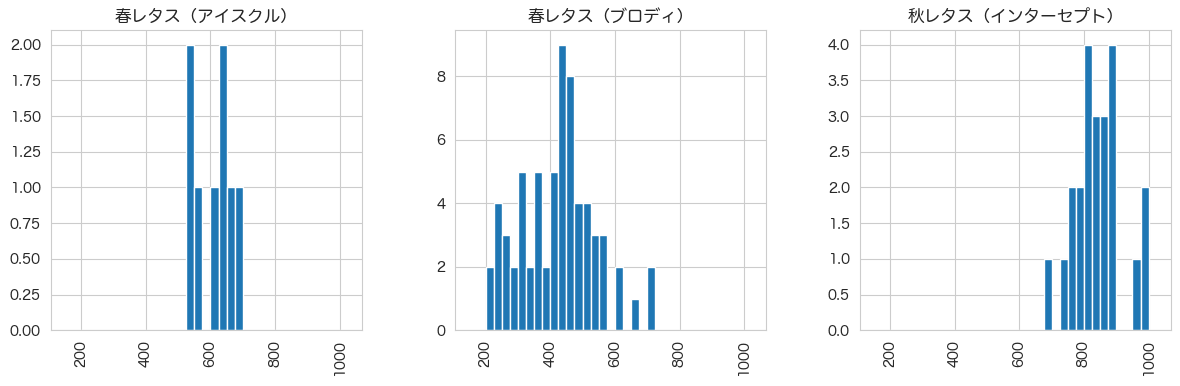

In [20]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "TMP_GDD4"
x_max = round((df_grow[elm].max() + 50)/50) * 50
x_min = round((df_grow[elm].min() - 50)/50) * 50
axes = df_grow.hist(elm, by='栽培グループ名', layout=(1,3), bins=np.arange(x_min, x_max, 25), figsize=(14,4))
plt.show()

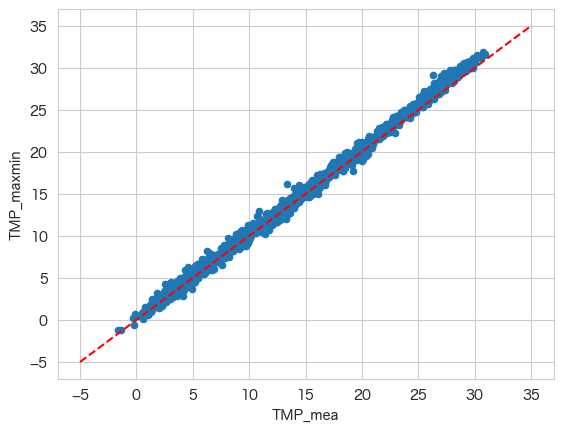

In [29]:
#--TMP_meaより、TMP_maxとTMP_minの平均の方がいいか？
# → ほぼ同じなので、どちらでもよい
df = df_weather['jpagri01'].copy()
df['TMP_maxmin'] = (df['TMP_max'] + df['TMP_min']) / 2
df.set_index('date', inplace=True)
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
df.plot.scatter(x='TMP_mea', y='TMP_maxmin', ax=ax)
ax.plot([-5,35], [-5,35], color='red', linestyle='--')
plt.show()

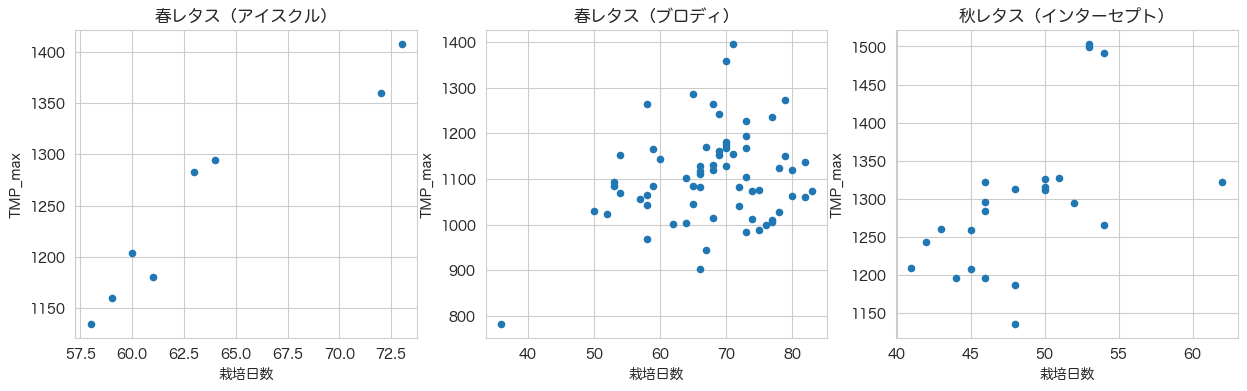

In [32]:
#--栽培グループごとに栽培日数と積算気温の散布図を作成
# 積算気温が支配的なら、栽培日数にかかわららず横一直線に近くなるはず
elm = "TMP_max"
fig = plt.figure(figsize=(15,4))
for i, (grp, df) in enumerate(df_grow.groupby('栽培グループ名')):
    ax = fig.add_subplot(1,3,i+1)
    df.plot.scatter(x='栽培日数', y=elm, title=grp, ax=ax)
plt.show()

#### 日射量や日照時間の積算値

In [33]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "GSR"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
春レタス（アイスクル）,1071.21,91.14,962.48,1231.02,8,0.09
春レタス（ブロディ）,1049.45,106.83,574.62,1237.43,66,0.10
秋レタス（インターセプト）,621.57,76.24,525.41,758.76,23,0.12


In [34]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
df_CV = pd.DataFrame()
for elm in ['SSD', 'GSR', 'DLR']:
    df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
    df_agg.columns = ['mean','std','min','max','count']
    df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
    df_CV[elm] = df_agg.get('CV')
# df_CV.round(2)

df_CV['best'] = df_CV.idxmin(axis=1)
# cols = df_CV.select_dtypes(include=[np.number]).columns
# df_CV['best'] = df_CV[cols].idxmin(axis=1)
display(df_CV['best'].value_counts())
display(df_CV.round(2))

# → TMP_maxが最もばらつきが少ない

best
DLR    2
SSD    1
Name: count, dtype: int64

,SSD,GSR,DLR,best
栽培グループ名,,,,
春レタス（アイスクル）,0.08,0.09,0.09,SSD
春レタス（ブロディ）,0.17,0.10,0.10,DLR
秋レタス（インターセプト）,0.23,0.12,0.07,DLR


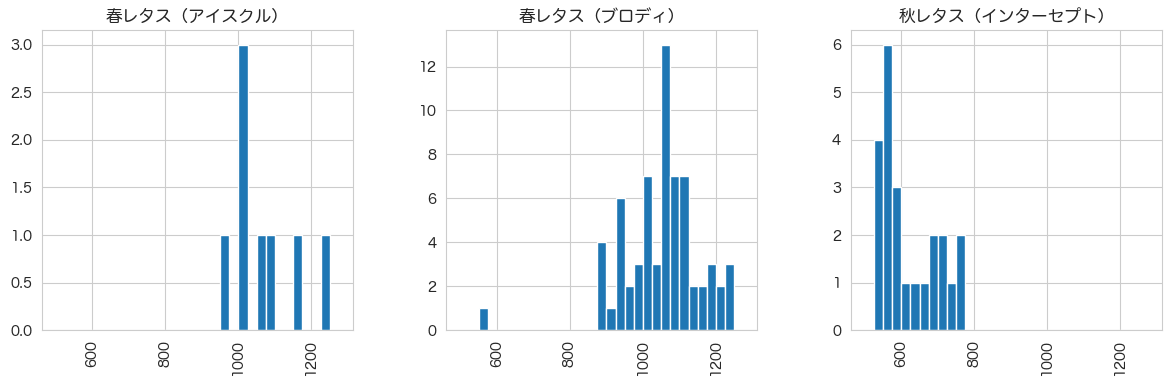

In [39]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "GSR"
x_max = round((df_grow[elm].max() + 50)/50) * 50
x_min = round((df_grow[elm].min() - 50)/50) * 50
axes = df_grow.hist(elm, by='栽培グループ名', layout=(1,3), bins=np.arange(x_min, x_max, 25), figsize=(14,4))
plt.show()

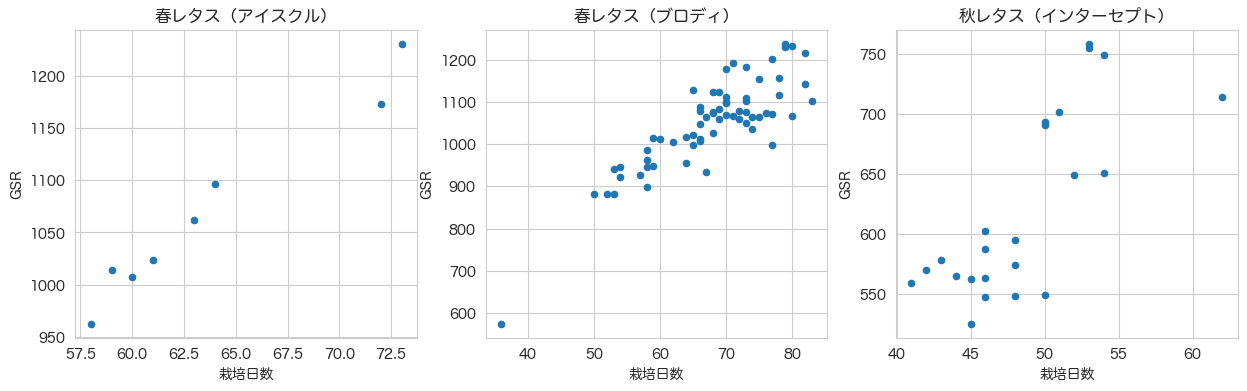

In [41]:
#--栽培グループごとに放射量関係の気象要素の散布図を作成
# 積算気温が支配的なら、栽培日数にかかわららず横一直線に近くなるはず
elm = "GSR"
fig = plt.figure(figsize=(15,4))
for i, (grp, df) in enumerate(df_grow.groupby('栽培グループ名')):
    ax = fig.add_subplot(1,3,i+1)
    df.plot.scatter(x='栽培日数', y=elm, title=grp, ax=ax)
plt.show()

#### 降水量積算値や平均湿度

In [42]:
#--湿度の平均値を計算しておく
df_grow['RH_mea'] = (df_grow['RH'] / df_grow['栽培日数']).round(2)

In [43]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "APCPRA"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
春レタス（アイスクル）,259.36,53.56,189.7,338.2,8,0.21
春レタス（ブロディ）,225.77,40.17,145.3,338.0,66,0.18
秋レタス（インターセプト）,199.72,80.42,102.0,316.2,23,0.40


In [44]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
df_CV = pd.DataFrame()
for elm in ['APCP', 'APCPRA']:
    df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
    df_agg.columns = ['mean','std','min','max','count']
    df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
    df_CV[elm] = df_agg.get('CV')
# df_CV.round(2)

df_CV['best'] = df_CV.idxmin(axis=1)
# cols = df_CV.select_dtypes(include=[np.number]).columns
# df_CV['best'] = df_CV[cols].idxmin(axis=1)
display(df_CV['best'].value_counts())
display(df_CV.round(2))

# → TMP_maxが最もばらつきが少ない

best
APCPRA    3
Name: count, dtype: int64

,APCP,APCPRA,best
栽培グループ名,,,
春レタス（アイスクル）,0.22,0.21,APCPRA
春レタス（ブロディ）,0.22,0.18,APCPRA
秋レタス（インターセプト）,0.41,0.40,APCPRA


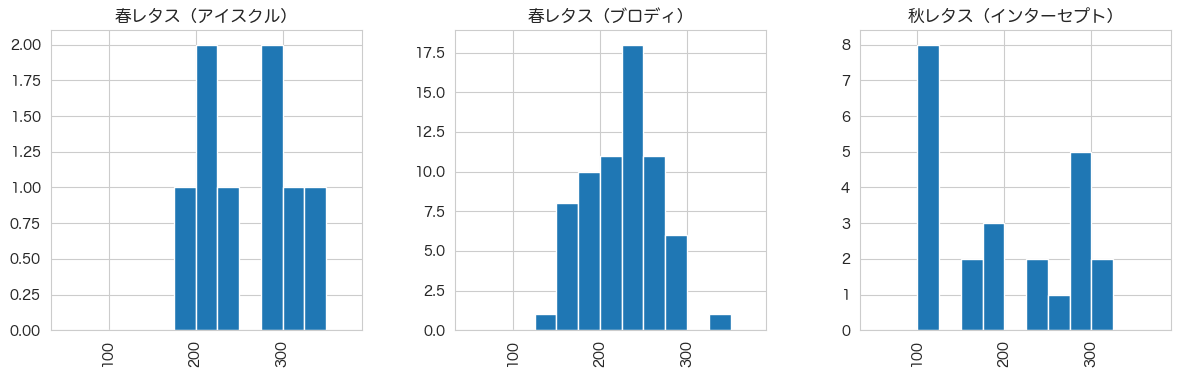

In [45]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "APCPRA"
x_max = round((df_grow[elm].max() + 50)/50) * 50
x_min = round((df_grow[elm].min() - 50)/50) * 50
axes = df_grow.hist(elm, by='栽培グループ名', layout=(1,3), bins=np.arange(x_min, x_max, 25), figsize=(14,4))
plt.show()

## NDVI値を曲線フィッティング

In [6]:
#--シグモイド関数を定義
def logistic4(x, a, K, b, x0):
    return a + (K - a) / (1.0 + np.exp(-b * (x - x0)))

In [7]:
#--画像出力先フォルダ作成
fig_dir = "fig/jpagri/sigmoid"
os.makedirs(fig_dir, exist_ok=True)

In [10]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
#--シグモイド関数でフィッティングした曲線と±2σの帯を表示
for group, df_group in df_farm.groupby('栽培グループ名'):
    #--シグモイド曲線でフィッティング
    x = df_group.dropna()['経過日'].values
    y = df_group.dropna()['NDVI値'].values

    a0  = y.min()  # 初期NDVI
    K0  = y.max()  # 最大NDVI
    x0_ = x.mean() # 立ち上がり中心
    b0  = 0.1      # 傾き（0.1〜0.2くらいから試す）
    p0 = [a0, K0, b0, x0_] # 初期パラメータ

    params, cov = curve_fit(logistic4, x, y, p0=p0, maxfev=10000)

    #--シグモイド曲線描画のための変数
    x_fit = np.linspace(x.min(), x.max(), 300)
    y_fit = logistic4(x_fit, *params)

    #--残差と標準偏差を計算し、±2σの帯を計算
    y_pred = logistic4(x, *params)
    residuals = y - y_pred
    sigma = np.std(residuals)
    upper = y_fit + 2*sigma
    lower = y_fit - 2*sigma

    #--グラフ描画（凡例は表示しない）
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', ax=ax)
    sns.lineplot(x=x_fit, y=y_fit, c='black', linestyle='--', ax=ax)
    ax.fill_between(x_fit, lower, upper, alpha=0.3)
    ax.set_title(group)
    #--画像保存 or 画像表示
    plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

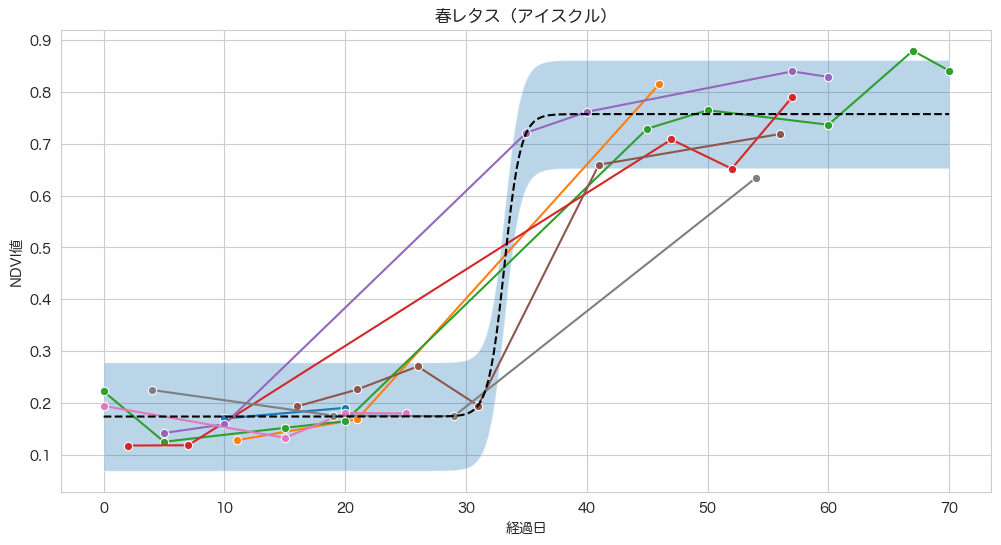

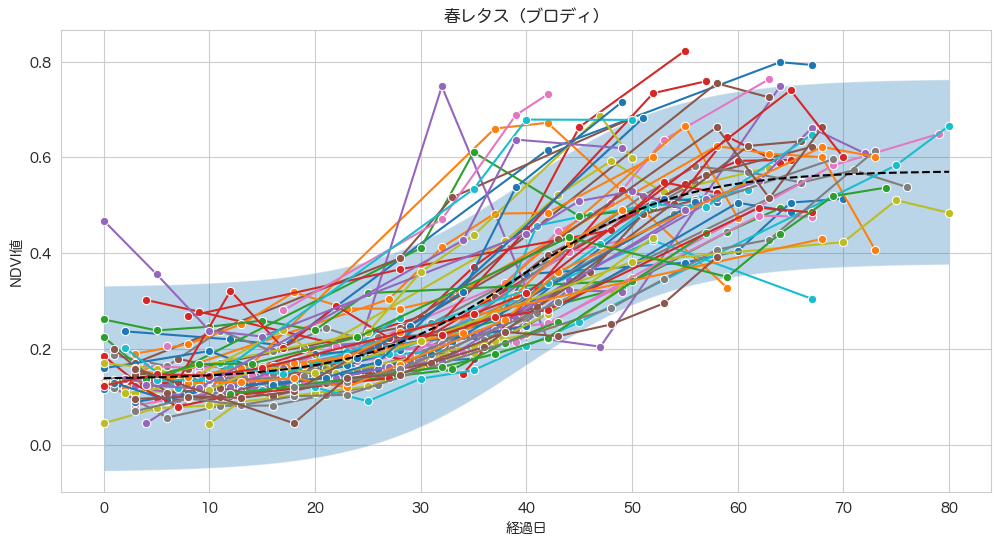

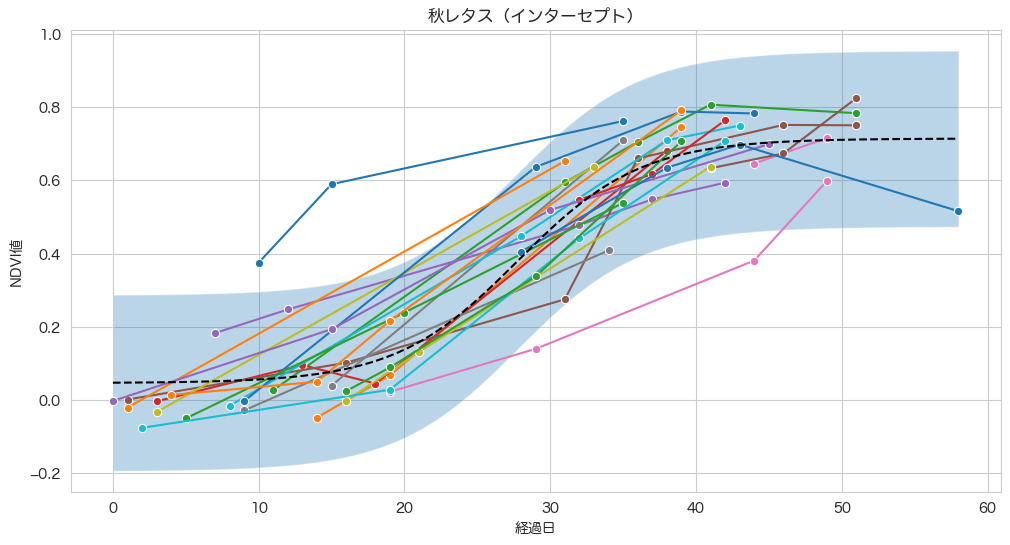

In [14]:
#--Notebook上での確認用
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
#--シグモイド関数でフィッティングした曲線と±2σの帯を表示
for group, df_group in df_farm.groupby('栽培グループ名'):
    #--シグモイド曲線でフィッティング
    x = df_group.dropna()['経過日'].values
    y = df_group.dropna()['NDVI値'].values

    a0  = y.min()  # 初期NDVI
    K0  = y.max()  # 最大NDVI
    x0_ = x.mean() # 立ち上がり中心
    b0  = 0.1      # 傾き（0.1〜0.2くらいから試す）
    p0 = [a0, K0, b0, x0_] # 初期パラメータ

    params, cov = curve_fit(logistic4, x, y, p0=p0, maxfev=10000)
    # a_fit, K_fit, b_fit, x0_fit = params

    #--シグモイド曲線描画のための変数
    x_fit = np.linspace(x.min(), x.max(), 300)
    y_fit = logistic4(x_fit, *params)

    #--残差と標準偏差を計算し、±2σの帯を計算
    y_pred = logistic4(x, *params)
    residuals = y - y_pred
    sigma = np.std(residuals)
    upper = y_fit + 2*sigma
    lower = y_fit - 2*sigma

    #--グラフ描画（凡例は表示しない）
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        # sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', ax=ax)
    # sns.lineplot(x=x_fit, y=y_fit, c='black', label='fitted curve', linestyle='--', ax=ax)
    sns.lineplot(x=x_fit, y=y_fit, c='black', linestyle='--', ax=ax)
    # ax.fill_between(x_fit, lower, upper, alpha=0.3, label='±2σ band')
    ax.fill_between(x_fit, lower, upper, alpha=0.3)
    # ax.legend()
    ax.set_title(group)
    #--画像保存 or 画像表示
    # plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    # plt.close()
    plt.show()
    # break

# END